# Drone Path Planning Using Cell Decomposition and A* Search

## Introduction
This poject demonstartes how the cell decomposition method can be used for motion planning in a city-like environment. The goal is to plan a safe path for a delivery drone from a launch pad to a delivery destination while avoiding obstacles.
The city is represented as a grid, where each cell is classified as either free or an obstacle. Buildings are treated as obstacles and there is a safety buffer added around them so the drone does not fly too close to them. AFter the environment is decomposed into cells, the problem turns into a graph search problem. the A* search algorithm to find the shortest path from start to goal. Then path smoothing is done wherever possible so the drone movement appears more natural.
The project checks multiple city types, evaluates the path and includes 2D and 3D visualisations of the output.

## Problem Definition & Formal Modeling

The drone path planning problem is modeled on a 2D grid representing a city environment. Each cell in the grid corresponds to a small region of space and is classified as either free or blocked.

We formally represent the environment as a graph:

G = (V, E)

where:
- V is the set of all grid cells (states)
- E is the set of valid transitions between cells based on allowed movements

### Inputs
- Grid size (rows × columns)
- Start position (launch pad)
- Goal position (delivery location)
- Buildings represented as obstacle regions
- Safety buffer size

### Outputs
- A valid path from start to goal (if one exists)
- Total path distance
- Number of explored cells
- Smoothed path for realistic motion

---

### State Space
Formally, the state space is:

S = { (r, c) | 0 ≤ r < rows, 0 ≤ c < cols }

Each state corresponds to a node in the graph.

In this problem each state is a cell represented as:
(r, c)

where r is the row and c is the column.

---

### Actions
These actions define the transition function:

T(s, a) → s'

where s' is the resulting state after applying action a to state s.

The drone can move in 8 directions:
- Up, Down, Left, Right (cost = 1)
- Diagonal directions (cost = √2)

---

### Constraints
A move is valid only if:
- The cell is inside the grid boundaries
- The cell is not blocked by a building
- The cell is not inside the safety buffer
- Diagonal movement does not cut through obstacles

---

### Cost Function
The total path cost is the sum of movement costs along the path:
- Orthogonal moves cost 1
- Diagonal moves cost √2
$$
g(n) = \sum_{i=1}^{k} cost(s_i, s_{i+1})
$$

where k is the number of steps in the path.

---

### Heuristic Function
The heuristic estimates the distance to the goal using Euclidean distance:
$$
h(n) = \sqrt((x_n - x_g)^2 + (y_n - y_g)^2)
$$

This heuristic is admissible and consistent, ensuring that A* finds an optimal path.

---

### Objective
Objective is to find the shortest valid path from the start position to the goal while avoiding obstacles and safety constraints, so to minimize this:

f(n) = g(n) + h(n)


## Algorithm Selection & Justification

The A* search algorithm is used to solve the path planning problem.

### A* Evaluation Function

$$
f(n) = g(n) + h(n)
$$

where:
- g(n) is the cost from the start node to node n  
- h(n) is the estimated cost from node n to the goal  

---

### Why A*?

A* is selected because it provides an optimal and efficient solution for grid-based path planning problems.

#### Comparison with other algorithms:

- **Breadth-First Search (BFS):**
  - Treats all moves equally (no cost differences)
  - Not suitable for weighted movement (diagonals vs straight)

- **Dijkstra’s Algorithm:**
  - Guarantees the shortest path
  - Explores many unnecessary nodes because it does not use a heuristic

- **A*:**
  - Uses a heuristic to guide the search
  - Explores fewer nodes than Dijkstra
  - Still guarantees an optimal solution

---

### Heuristic Properties

The Euclidean distance heuristic is used:

$$
h(n) = \sqrt{(x_n - x_g)^2 + (y_n - y_g)^2}
$$

This heuristic is:

- **Admissible**: it never overestimates the true cost  
- **Consistent**: ensures optimality and efficient search  

---

### Complexity

Let V be the number of grid cells.

- Time Complexity:
  $$O((V + E)\log V) \approx O(V \log V)$$

- Space Complexity:
  $$O(V)$$

In practice, the heuristic significantly reduces the number of explored nodes, making A* efficient for this problem.

In the worst case, when the heuristic provides little to no useful guidance (e.g., in highly constrained environments), A* behaves similarly to Dijkstra’s algorithm and explores most of the grid, leading to:

- Worst-case time complexity: O(V log V)

However, in typical scenarios, the heuristic significantly improves performance by guiding the search toward the goal.

- With a good heuristic, the number of explored nodes is greatly reduced
- The algorithm focuses on promising paths instead of exploring uniformly

This makes the practical runtime much closer to:

- O(b^d)

where:
- b is the branching factor
- d is the depth of the optimal solution

---

### Effect of the Heuristic

The efficiency of A* depends heavily on the heuristic function:

- A more accurate heuristic → fewer explored nodes  
- A weak heuristic → behavior closer to Dijkstra  

The Euclidean distance heuristic used in this project is both:
- Admissible (guarantees optimality)
- Consistent (ensures no node is re-expanded unnecessarily)

## City & Grid Generation

The city environment is generated as a 2D grid. Buildings are represented as rectangular obstacle regions. Each building has:

- row boundaries
- column boundaries
- height value for 3D visualization

Several different city types are created to test the algorithm under different conditions:

- Sparse City: fewer obstacles
- Dense City: more obstacles
- Narrow Passage: tight corridor-like layout
- Blocked Path: intentionally impossible path

The start and goal areas are protected so buildings do not overlap with the launch pad or delivery destination.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import plotly.graph_objects as go

#Sets the city size, 35x35

rows, cols = 35, 35
start = (2, 2)
goal = (32, 25)

#Checks if start or goal points are inside the builindings
def overlaps_start_or_goal(r1, r2, c1, c2, start, goal, margin=2):
    protected_points = [start, goal]

    for point in protected_points:
        r, c = point
        if r1 - margin <= r <= r2 + margin and c1 - margin <= c <= c2 + margin:
            return True

    return False

#Generates random sized buildings and makes a list of them
def generate_random_buildings(rows, cols, start, goal,
                         num_buildings=8,
                         min_size=3,
                         max_size=7,
                         min_height=12,
                         max_height=28):
    buildings = []
    attempts = 0

    while len(buildings) < num_buildings and attempts < 1000:
        attempts += 1

        h = np.random.randint(min_size, max_size + 1)
        w = np.random.randint(min_size, max_size + 1)

        r1 = np.random.randint(0, rows - h)
        c1 = np.random.randint(0, cols - w)

        r2 = r1 + h
        c2 = c1 + w

        if overlaps_start_or_goal(r1, r2, c1, c2, start, goal):
            continue

        height = np.random.randint(min_height, max_height + 1)
        buildings.append((r1, r2, c1, c2, height))

    return buildings

#Below are the different types of cities that ca be generated according to the ammount of buildings in them
def generate_sparse_city(rows, cols, start, goal):
    return generate_random_buildings(
        rows, cols, start, goal,
        num_buildings=5,
        min_size=3,
        max_size=6,
        min_height=12,
        max_height=22
    )


def generate_dense_city(rows, cols, start, goal):
    return generate_random_buildings(
        rows, cols, start, goal,
        num_buildings=12,
        min_size=3,
        max_size=6,
        min_height=15,
        max_height=30
    )


def generate_narrow_city(rows, cols, start, goal):
    buildings = []

    left_wall_col = np.random.randint(9, 12)
    corridor_width = np.random.randint(3,5)
    right_wall_col = left_wall_col + corridor_width + 3

    buildings.append((5, 30, left_wall_col, left_wall_col + 3, 26))
    buildings.append((5, 30, right_wall_col, right_wall_col + 3, 26))

    buildings.append((10, 16, 2, 7, 18))
    buildings.append((20, 27, 2, 7, 20))
    buildings.append((8, 14, 27, 32, 18))
    buildings.append((21, 28, 27, 32, 20))

    return buildings


def generate_blocked_city(rows, cols, start, goal):
    gap_decoy = np.random.randint(5, 25)

    return [
        (12, 23, 0, cols, 28),
        (3, 8, gap_decoy, min(gap_decoy + 5, cols), 18),
        (26, 31, max(gap_decoy - 5, 0), gap_decoy, 18)
    ]

## City Type Selection

The user can choose one of four city types. This makes the program interactive and allows the algorithm to be tested under different conditions.

The available types are:

1. Sparse City — fewer buildings and easier navigation  
2. Dense City — more buildings and more difficult navigation  
3. Narrow City — a tight corridor that tests precision  
4. Blocked City — an intentionally impossible case used to test failure handling

In [2]:
#In this part the user chooses what kind of city they want to generate
print("Choose a city type:")
print("1. Sparse City")
print("2. Dense City")
print("3. Narrow Passage")
print("4. Blocked Path")

choice = input("Enter choice: ")

if choice == "1":
    city_type = "Sparse City"
    buildings = generate_sparse_city(rows, cols, start, goal)

elif choice == "2":
    city_type = "Dense City"
    buildings = generate_dense_city(rows, cols, start, goal)

elif choice == "3":
    city_type = "Narrow Passage"
    buildings = generate_narrow_city(rows, cols, start, goal)

elif choice == "4":
    city_type = "Blocked Path"
    buildings = generate_blocked_city(rows, cols, start, goal)

else:
    print("Invalid choice. Defaulting to Dense City.")
    city_type = "Dense City"
    buildings = generate_dense_city(rows, cols, start, goal)

print(f"\nSelected randomized city type: {city_type}")

Choose a city type:
1. Sparse City
2. Dense City
3. Narrow Passage
4. Blocked Path
Enter choice: 2

Selected randomized city type: Dense City


## Safety Buffer and Occupancy Grid

After the buildings are generated, they are converted into a grid representation.

Two maps are created:

- `grid`: used for path planning  
  - 0 means free cell  
  - 1 means blocked cell  

- `height_map`: used for visualization  
  - 0 means empty space  
  - positive values represent building or platform height  

A safety buffer is added around buildings. This expands obstacle regions so the drone does not fly too close to buildings.

For the Narrow Passage scenario, the buffer is set to 0 because adding a buffer would close the passage completely.

In [3]:
#Creates the final grid of the buildings and their heights
def generate_city(rows, cols, buildings, start, goal):
    grid = np.zeros((rows, cols))
    height_map = np.zeros((rows, cols))

    for r1, r2, c1, c2, h in buildings:
        grid[r1:r2, c1:c2] = 1
        height_map[r1:r2, c1:c2] = h

    height_map[start[0]-1:start[0]+2, start[1]-1:start[1]+2] = 2
    height_map[goal[0]-1:goal[0]+2, goal[1]-1:goal[1]+2] = 2

    grid[start[0]-1:start[0]+2, start[1]-1:start[1]+2] = 0
    grid[goal[0]-1:goal[0]+2, goal[1]-1:goal[1]+2] = 0

    return grid, height_map


grid, height_map = generate_city(rows, cols, buildings, start, goal)

#Adds the buffer to the buildings so the drone does not fly to close to them for safety
def add_safety_buffer(grid, buffer_size=1):
    buffered_grid = grid.copy()
    obstacle_cells = np.argwhere(grid == 1)

    for r, c in obstacle_cells:
        for dr in range(-buffer_size, buffer_size + 1):
            for dc in range(-buffer_size, buffer_size + 1):
                nr = r + dr
                nc = c + dc

                if 0 <= nr < grid.shape[0] and 0 <= nc < grid.shape[1]:
                    buffered_grid[nr, nc] = 1

    return buffered_grid

#In case of the narrow city the buffer is zero so the path can be found
if city_type == "Narrow Passage":
    buffer_size = 0
else:
    buffer_size = 1

planning_grid = add_safety_buffer(grid, buffer_size)

planning_grid[start[0]-1:start[0]+2, start[1]-1:start[1]+2] = 0
planning_grid[goal[0]-1:goal[0]+2, goal[1]-1:goal[1]+2] = 0


## A* Implementation and Path Smoothing

The A* algorithm is used to search for the shortest path on the buffered planning grid.

The algorithm uses:

- `open_set`: priority queue of cells still waiting to be explored
- `came_from`: stores the parent of each visited cell for path reconstruction
- `g_score`: stores the actual cost from the start to each cell
- `visited`: stores cells that have already been processed
- `explored`: stores all explored cells for visualization

After A* finds a path, a smoothing function is applied. The smoothing function checks whether two non-adjacent path points can be directly connected without crossing obstacles. If they can, unnecessary intermediate points are removed.

In [4]:
def heuristic(a, b):
    return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2) #euclidian distance


def reconstruct_path(came_from, current, start):
    path = []

    while current in came_from:
        path.append(current)
        current = came_from[current]

    path.append(start)
    return path[::-1]


def astar(grid, start, goal):
    rows, cols = grid.shape

    open_set = [] #cells that are still not explored
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0} #cost from start to the point

    explored = []
    visited = set() #processed cells

    moves = [
        (1, 0, 1), (-1, 0, 1),
        (0, 1, 1), (0, -1, 1),
        (1, 1, np.sqrt(2)), (1, -1, np.sqrt(2)),
        (-1, 1, np.sqrt(2)), (-1, -1, np.sqrt(2))
    ]

    while open_set: #while there are still unexplored cells the alorithm checks all the neighbouring ones and chooses the cheapest
        _, current = heapq.heappop(open_set)

        if current in visited:
            continue

        visited.add(current)
        explored.append(current)

        if current == goal:
            return reconstruct_path(came_from, current, start), explored

        for dr, dc, move_cost in moves:
            nr = current[0] + dr
            nc = current[1] + dc
            neighbor = (nr, nc)

            if not (0 <= nr < rows and 0 <= nc < cols):
                continue

            if grid[nr, nc] == 1:
                continue

            # Prevent diagonal corner-cutting
            if dr != 0 and dc != 0:
                if grid[current[0] + dr, current[1]] == 1:
                    continue
                if grid[current[0], current[1] + dc] == 1:
                    continue

            tentative_g = g_score[current] + move_cost

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g

                f_score = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score, neighbor))

    return None, explored


#after the path is found if there are any points on it that can be directly connected the path is smoothed. distance does not change much but the amount of cells reduces
def has_visibility(grid, p1, p2):
    r1, c1 = p1
    r2, c2 = p2

    steps = max(abs(r2 - r1), abs(c2 - c1))

    if steps == 0:
        return True

    for i in range(steps + 1):
        t = i / steps
        r = round(r1 + t * (r2 - r1))
        c = round(c1 + t * (c2 - c1))

        if grid[r, c] == 1:
            return False

    return True


def smooth_path(grid, path):
    if path is None or len(path) < 3:
        return path

    smoothed = [path[0]]
    i = 0

    while i < len(path) - 1:
        j = len(path) - 1

        while j > i + 1:
            if has_visibility(grid, path[i], path[j]):
                break
            j -= 1

        smoothed.append(path[j])
        i = j

    return smoothed


path, explored = astar(planning_grid, start, goal)

if path:
    smoothed_path = smooth_path(planning_grid, path)
else:
    smoothed_path = None


## How A* Works in This Implementation

The A* algorithm searches for the shortest path on the buffered grid by combining actual cost and estimated cost.

### Step-by-step process

1. The algorithm starts at the start cell and adds it to a priority queue.
2. At each step, it selects the cell with the lowest total estimated cost:
   
   f(n) = g(n) + h(n)

3. The algorithm explores all valid neighboring cells:
   - Only cells inside the grid are considered
   - Blocked cells are skipped
   - Diagonal moves are restricted to prevent cutting through corners

4. For each neighbor:
   - The new cost g(n) is calculated
   - If this path is better than a previous one, it is updated

5. The process continues until:
   - The goal is reached → path is reconstructed
   - Or no path exists → algorithm returns no solution

---

### Path Reconstruction

Once the goal is reached, the path is reconstructed by tracing backwards using the `came_from` dictionary. The path is then reversed to give the correct order from start to goal.

---

### Path Smoothing

The original A* path follows the grid and may contain many sharp turns.

To improve this:
- The algorithm checks if two points on the path can be directly connected
- If there are no obstacles between them, intermediate points are removed

This results in:
- Fewer path points
- Smoother trajectory
- More natural drone movement

---

### Why this works well

- A* guarantees the shortest path when the heuristic is admissible
- The safety buffer ensures safe navigation
- Path smoothing improves the realism of the movement without affecting correctness

## Evaluation and Results

This section evaluates the performance of the A* algorithm on the selected city type.

The following metrics are reported:

- Whether a valid path was found
- Number of buildings in the environment
- Safety buffer size
- Number of cells in the original A* path
- Number of cells in the smoothed path
- Total path distance (original and smoothed)
- Number of explored cells


In [5]:
#Calculates the distance
def path_distance(path):
    if path is None:
        return None

    total = 0

    for i in range(1, len(path)):
        total += heuristic(path[i - 1], path[i])

    return total

#Prints out all the information abuot the path
print("\n--- Results ---")
print("City type:", city_type)
print("Buildings generated:", len(buildings))
print("Safety buffer size:", buffer_size)
print("Path found:", path is not None)

if path:
    print("Original path cells:", len(path))
    print("Smoothed path points:", len(smoothed_path))
    print("Original path distance:", round(path_distance(path), 2))
    print("Smoothed path distance:", round(path_distance(smoothed_path), 2))
else:
    print("No valid path found.")

print("Explored cells:", len(explored))


--- Results ---
City type: Dense City
Buildings generated: 12
Safety buffer size: 1
Path found: True
Original path cells: 32
Smoothed path points: 3
Original path distance: 40.11
Smoothed path distance: 38.36
Explored cells: 201


## Results Interpretation

The printed results show whether the algorithm successfully found a path for the selected city type.

If a path is found, the original A* path and the smoothed path are compared. The smoothed path usually contains fewer points because unnecessary intermediate grid cells are removed. This makes the drone movement more natural while still avoiding obstacles.

The path distance shows the total length of the route. The smoothed path distance may be similar to or slightly shorter than the original path distance because it connects safe points more directly.

The number of explored cells shows how much work the A* algorithm performed. A larger number of explored cells usually means the environment was more difficult to search, such as in dense or narrow city layouts.

In the blocked path scenario, the expected result is that no valid path is found. This is important because it shows that the algorithm can correctly detect when the goal is unreachable.

## 2D Visualization

This visualization shows the city grid from a top-down view.

- Buildings are displayed in grayscale
- Safety buffer zones are shown in light red
- Explored cells are shown in orange
- The original A* path is shown as a dashed gray line
- The smoothed path is shown in red
- The start and goal positions are highlighted

This visualization helps understand how the algorithm explores the grid and how the final path avoids obstacles.

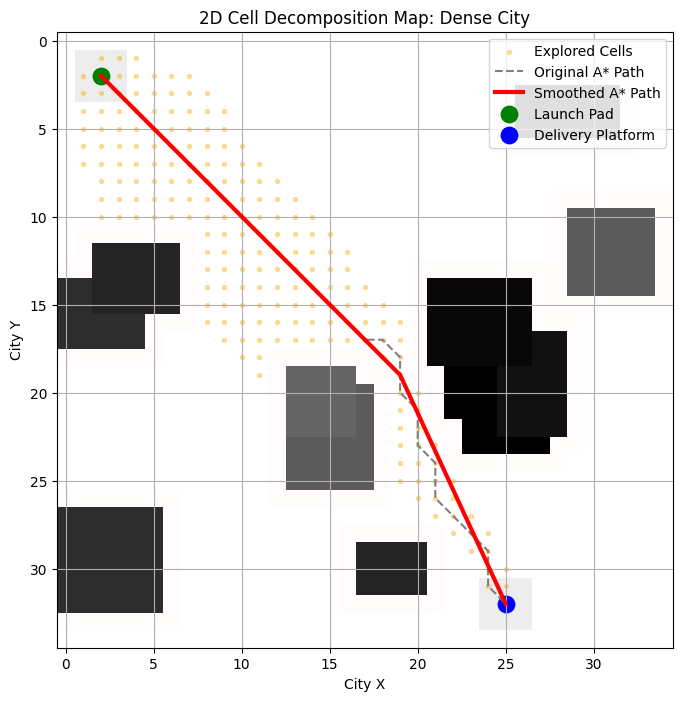

In [6]:
#2D map of the path in the city
plt.figure(figsize=(8, 8))
plt.imshow(height_map, cmap="gray_r")

buffer_only = np.logical_and(planning_grid == 1, grid == 0)
buffer_display = np.ma.masked_where(buffer_only == 0, buffer_only)
plt.imshow(buffer_display, cmap="Reds", alpha=0.25)

explored_x = [p[1] for p in explored]
explored_y = [p[0] for p in explored]

plt.scatter(
    explored_x,
    explored_y,
    color="orange",
    s=8,
    alpha=0.35,
    label="Explored Cells"
)

if path:
    original_x = [p[1] for p in path]
    original_y = [p[0] for p in path]

    plt.plot(
        original_x,
        original_y,
        color="gray",
        linewidth=1.5,
        linestyle="--",
        label="Original A* Path"
    )

if smoothed_path:
    smooth_x = [p[1] for p in smoothed_path]
    smooth_y = [p[0] for p in smoothed_path]

    plt.plot(
        smooth_x,
        smooth_y,
        color="red",
        linewidth=3,
        label="Smoothed A* Path"
    )

plt.scatter(start[1], start[0], color="green", s=140, label="Launch Pad")
plt.scatter(goal[1], goal[0], color="blue", s=140, label="Delivery Platform")

plt.title(f"2D Cell Decomposition Map: {city_type}")
plt.xlabel("City X")
plt.ylabel("City Y")
plt.legend()
plt.grid(True)
plt.show()

## 3D Interactive Visualization

The 3D visualization represents the city environment with building heights and an animated drone path.

- Buildings are shown as 3D blocks
- The launch pad is shown in green
- The delivery platform is shown in blue
- Safety buffer zones are shown as low transparent red blocks
- The smoothed drone path is shown in red
- The drone animation shows movement from start to goal

This makes the result easier to interpret and demonstrates how the planned path would look in a city-like environment.

In [7]:
FLIGHT_ALTITUDE = 6

if smoothed_path:
    path_altitudes = [FLIGHT_ALTITUDE for _ in smoothed_path]

#3D visualisation of how the drone flies to destination point with found path
fig = go.Figure()


def add_box(fig, x, y, h, color, opacity=0.75):
    fig.add_trace(go.Mesh3d(
        x=[x, x+1, x+1, x, x, x+1, x+1, x],
        y=[y, y, y+1, y+1, y, y, y+1, y+1],
        z=[0, 0, 0, 0, h, h, h, h],
        i=[0, 0, 0, 1, 4, 5, 6, 7, 0, 1, 2, 3],
        j=[1, 2, 3, 2, 5, 6, 7, 4, 4, 5, 6, 7],
        k=[2, 3, 0, 3, 6, 7, 4, 5, 5, 6, 7, 4],
        color=color,
        opacity=opacity,
        showscale=False,
        hoverinfo="skip"
    ))


for r in range(rows):
    for c in range(cols):
        h = height_map[r, c]

        if h > 0:
            if abs(r - start[0]) <= 1 and abs(c - start[1]) <= 1:
                color = "green"
            elif abs(r - goal[0]) <= 1 and abs(c - goal[1]) <= 1:
                color = "royalblue"
            else:
                color = "lightgray"

            add_box(fig, c, r, h, color)


for r in range(rows):
    for c in range(cols):
        if planning_grid[r, c] == 1 and grid[r, c] == 0:
            add_box(fig, c, r, 0.3, "red", opacity=0.15)


if smoothed_path:
    xs = [p[1] + 0.5 for p in smoothed_path]
    ys = [p[0] + 0.5 for p in smoothed_path]
    zs = path_altitudes

    fig.add_trace(go.Scatter3d(
        x=xs,
        y=ys,
        z=zs,
        mode="lines",
        line=dict(color="red", width=9),
        name="Smoothed Drone Path"
    ))

    fig.add_trace(go.Scatter3d(
        x=[xs[0]],
        y=[ys[0]],
        z=[zs[0]],
        mode="markers",
        marker=dict(size=9, color="purple"),
        name="Drone"
    ))

    fig.add_trace(go.Scatter3d(
        x=[xs[0]],
        y=[ys[0]],
        z=[zs[0]],
        mode="lines",
        line=dict(color="purple", width=6),
        name="Drone Trail"
    ))

    drone_trace_index = len(fig.data) - 2
    trail_trace_index = len(fig.data) - 1

    frames = []

    for i in range(len(xs)):
        frames.append(go.Frame(
            data=[
                go.Scatter3d(
                    x=[xs[i]],
                    y=[ys[i]],
                    z=[zs[i]],
                    mode="markers",
                    marker=dict(size=9, color="purple"),
                    name="Drone"
                ),
                go.Scatter3d(
                    x=xs[:i + 1],
                    y=ys[:i + 1],
                    z=zs[:i + 1],
                    mode="lines",
                    line=dict(color="purple", width=6),
                    name="Drone Trail"
                )
            ],
            traces=[drone_trace_index, trail_trace_index],
            name=str(i)
        ))

    fig.frames = frames

    updatemenus = [
        dict(
            type="buttons",
            showactive=False,
            x=0.05,
            y=0,
            buttons=[
                dict(
                    label="Fly Drone",
                    method="animate",
                    args=[
                        None,
                        dict(
                            frame=dict(duration=130, redraw=True),
                            transition=dict(duration=0),
                            fromcurrent=True,
                            mode="immediate"
                        )
                    ]
                ),
                dict(
                    label="Pause",
                    method="animate",
                    args=[
                        [None],
                        dict(
                            frame=dict(duration=0, redraw=False),
                            mode="immediate"
                        )
                    ]
                )
            ]
        )
    ]

else:
    updatemenus = []


fig.update_layout(
    title=f"Interactive 2.5D Drone Flight with Smoothed Path: {city_type}",
    width=1000,
    height=800,
    scene=dict(
        xaxis_title="City X",
        yaxis_title="City Y",
        zaxis_title="Altitude",
        xaxis=dict(range=[0, cols]),
        yaxis=dict(range=[0, rows]),
        zaxis=dict(range=[0, 32]),
        aspectmode="manual",
        aspectratio=dict(x=1, y=1, z=0.45),
        camera=dict(
            eye=dict(x=1.7, y=-1.7, z=1.2)
        )
    ),
    updatemenus=updatemenus
)

fig.show()